<a href="https://colab.research.google.com/github/NavdeeepSinghh/Deep_Learning-LAB/blob/main/Lab_6_Learning_t_o_Bend_a_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 1 — Create a Simple Dataset

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


X shape : (50, 1)   (50 samples, 1 feature)
y shape : (50, 1)   (50 samples, 1 target)
X range : [0.0, 10.0]
y range : [0.099, 2.572]


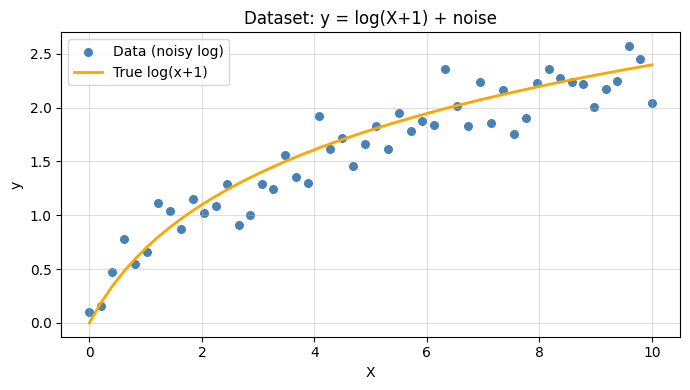

In [ ]:
np.random.seed(42)

X = np.linspace(0, 10, 50).reshape(-1, 1)   # shape: (50, 1)

noise = np.random.normal(0, 0.2, size=(50, 1))   # small noise, std=0.2
y     = np.log(X + 1) + noise                    # shape: (50, 1)
print(f'X shape : {X.shape}   (50 samples, 1 feature)')
print(f'y shape : {y.shape}   (50 samples, 1 target)')
print(f'X range : [{X.min():.1f}, {X.max():.1f}]')
print(f'y range : [{y.min():.3f}, {y.max():.3f}]')
plt.figure(figsize=(7, 4))
plt.scatter(X, y, color='steelblue', s=30, label='Data (noisy log)')
plt.plot(X, np.log(X + 1), color='orange', linewidth=2, label='True log(x+1)')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Dataset: y = log(X+1) + noise')
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

## Step 2 — Decide the Model Shape (No Code Yet)


# How many hidden units do we want?  → 3
#
# Why more than 1?
#   A single hidden unit applies the same bend everywhere.
#   With 3 units, the network can create 3 different 'pieces' of behavior
#   and combine them — giving it enough flexibility to track a concave curve.
#
# Why not too many (e.g. 50)?
#   More units = more parameters = higher risk of overfitting the 50 noisy
#   samples. Training also becomes less stable. For a smooth 1D function,
#   3 hidden units is a good balance between capacity and stability.
#
# Architecture:  1 → 3 → 1
#   Input layer  : 1 feature (X)
#   Hidden layer : 3 neurons with ReLU activation
#   Output layer : 1 neuron, linear (regression output)

## Step 3 — Initialize Model Parameters

In [ ]:
np.random.seed(0)
W1 = np.random.uniform(-1, 1, size=(1, 3))   # shape (1, 3)
b1 = np.zeros((1, 3))                         # shape (1, 3)
W2 = np.random.uniform(-1, 1, size=(3, 1))   # shape (3, 1)
b2 = np.zeros((1, 1))                         # shape (1, 1)

# Comment — what each parameter controls:
#
# W1  → controls the SHAPE of the hidden activations.
#        Each column of W1 scales X differently for each hidden neuron,
#        determining how steeply and in which direction each unit responds.
#        W1 is the primary bending mechanism.
#
# b1  → shifts (translates) the activation input left or right for each
#        hidden neuron — controls WHERE on the x-axis the bend begins.
#
# W2  → controls how much each hidden unit's output contributes to the
#        final prediction. Positive W2 amplifies; negative W2 inverts.
#
# b2  → shifts the final output up or down — a global vertical offset.
#
# In summary:
#   Weights (W1, W2) → affect SHAPE (slope, bending, scaling)
#   Biases  (b1, b2) → affect POSITION (vertical/horizontal shift)

print('Parameters initialized:')
print(f'  W1 shape: {W1.shape}  — input→hidden weights')
print(f'  b1 shape: {b1.shape}  — hidden bias')
print(f'  W2 shape: {W2.shape}  — hidden→output weights')
print(f'  b2 shape: {b2.shape}  — output bias')

Parameters initialized:
  W1 shape: (1, 3)  — input→hidden weights
  b1 shape: (1, 3)  — hidden bias
  W2 shape: (3, 1)  — hidden→output weights
  b2 shape: (1, 1)  — output bias


## Step 4 — Define an Activation Function


In [ ]:
def activation(z):
    """
    ReLU activation: keeps positive values, suppresses negative ones.
    ReLU(z) = max(0, z)

    Why ReLU?
    - Simple and fast to compute
    - Does not squash large positive values (no vanishing gradient for z>0)
    - Creates piecewise-linear 'bends' — multiple units together approximate
      any smooth curve
    """
    # Implement: keep positive values, suppress (zero out) negative values
    return np.maximum(0, z)


# ── Task 4.2 — Activation slope (derivative) ─────────────────────────────────

def activation_slope(z):
    """
    Derivative of ReLU.
    d/dz ReLU(z) = 1  if z > 0
                 = 0  if z <= 0

    Slope must be:
    - zero in the negative region (z <= 0)   — no gradient flows through dead neurons
    - non-zero (= 1) in the positive region  — gradient passes unchanged
    """
    # Return 1 where z > 0, 0 elsewhere
    return (z > 0).astype(float)


# Comment — why slope matters for learning:
# During backpropagation, gradients are multiplied by the activation slope
# at each neuron (chain rule). Without a slope, the gradient signal is zero —
# the model receives no information about which direction to change parameters.
# The slope tells us: 'how sensitive is the output to a small change in input?'
# Without this directional signal, learning cannot happen.

# Quick sanity check
test_z = np.array([-2.0, -0.5, 0.0, 1.0, 3.0])
print('Activation check:')
print(f'  z              : {test_z}')
print(f'  activation(z)  : {activation(test_z)}')
print(f'  slope(z)       : {activation_slope(test_z)}')

Activation check:
  z              : [-2.  -0.5  0.   1.   3. ]
  activation(z)  : [0. 0. 0. 1. 3.]
  slope(z)       : [0. 0. 0. 1. 1.]



## Step 5 — Forward Pass

$$z_1 = XW_1 + b_1 \qquad h = \text{activation}(z_1) \qquad \hat{y} = hW_2 + b_2$$

In [ ]:
def forward_pass(X, W1, b1, W2, b2):
    """
    Computes prediction y_hat and caches intermediate values for backprop.
    Returns: y_hat, z1, h
    """
    # Step 1: Linear transformation — input → hidden pre-activation
    # z1 = X @ W1 + b1
    # Maps the raw input into a 3-dimensional hidden space.
    # Each column of W1 scales X differently for each hidden neuron.
    z1 = X @ W1 + b1          # shape: (50, 1) @ (1, 3) + (1, 3) → (50, 3)

    # Step 2: Non-linear activation — apply ReLU to create bending
    # h = activation(z1)
    # Without this step, z1 is still linear in X, and stacking another
    # linear layer (W2) would collapse back to a single linear function.
    # The activation is what truly lets the model 'bend'.
    h = activation(z1)         # shape: (50, 3)

    # Step 3: Output prediction — hidden → output (linear, no activation)
    # y_hat = h@W2+b2
    # Linear output is correct for regression — we don't want to squash
    # the predicted value into a fixed range.
    y_hat = h @ W2 + b2        # shape: (50, 3) @ (3, 1) + (1, 1) → (50, 1)

    return y_hat, z1, h


# Test forward pass with initial parameters
y_hat_init, z1_init, h_init = forward_pass(X, W1, b1, W2, b2)
print('Forward pass shape check:')
print(f'  z1    shape: {z1_init.shape}   (50 samples × 3 hidden units)')
print(f'  h     shape: {h_init.shape}   (50 samples × 3 hidden activations)')
print(f'  y_hat shape: {y_hat_init.shape}   (50 samples × 1 output)')

Forward pass shape check:
  z1    shape: (50, 3)   (50 samples × 3 hidden units)
  h     shape: (50, 3)   (50 samples × 3 hidden activations)
  y_hat shape: (50, 1)   (50 samples × 1 output)


## Step 6 — Define Error and Loss

$$L = \frac{1}{N} \sum (\hat{y} - y)^2$$

In [ ]:

# Compute error = prediction - actual
# Positive error → model over-predicted → we need to decrease y_hat
# Negative error → model under-predicted → we need to increase y_hat
# This signed difference is what drives the gradient direction.

def compute_error(y_hat, y):
    return y_hat - y       # shape: (50, 1)


#  Task 6.2  Loss(MSE)

def compute_loss(error):
    """
    Mean Squared Error: L = (1/N) * sum( error^2 )
    Returns a single scalar.
    """
    # Compute loss — a single scalar we want to minimize
    loss = np.mean(error ** 2)
    return loss

# Comment — why large errors matter more than small ones here:
# Squaring the error amplifies large mistakes non-linearly:
#   error = 1  →  squared = 1
#   error = 2  →  squared = 4   (4× worse, not 2×)
#   error = 5  →  squared = 25  (25× worse, not 5×)
# This forces the model to aggressively correct its worst predictions first,
# rather than tolerating a few large mistakes in favour of many small ones.

# Quick check with initial parameters
err_init  = compute_error(y_hat_init, y)
loss_init = compute_loss(err_init)
print(f'Initial loss (before any training): {loss_init:.4f}')


Initial loss (before any training): 2.8223


## Step 7 — Why We Need Slopes (Conceptual Stop)


In [ ]:
# To reduce loss, we must change parameters.
# To know HOW to change them, we need to know:
#   if a small increase in each parameter increases or decreases loss.
#
# This is exactly what a gradient (slope) tells us.
#
# Gradient = slope of the loss surface at the current parameter value.
#
# If gradient > 0  →  increasing this parameter raises loss  →  decrease it
# If gradient < 0  →  increasing this parameter lowers loss  →  increase it
#
# Without slopes, we have no direction — learning is impossible.
# This is the entire reason backpropagation (organized slope computation) exists.

print('Step 7 — Conceptual checkpoint:')
print('  Gradient = slope of loss surface at current parameter value.')
print('  Subtracting the gradient moves parameters downhill → reduces loss.')
print('  Without slopes, there is no direction → no learning.')


Step 7 — Conceptual checkpoint:
  Gradient = slope of loss surface at current parameter value.
  Subtracting the gradient moves parameters downhill → reduces loss.
  Without slopes, there is no direction → no learning.


#Step 8 — Backward Flow

We compute gradients using the **chain rule**, flowing error from output → input.

$$\frac{\partial L}{\partial \hat{y}} = 2(\hat{y}-y) \qquad \frac{\partial \hat{y}}{\partial W_2} = h \qquad \frac{\partial \hat{y}}{\partial h} = W_2 \qquad \frac{\partial h}{\partial z_1} = \text{activation\_slope}(z_1)$$

In [ ]:
def backward_pass(X, y, y_hat, z1, h, W2):
    """
    Computes all gradients via backpropagation.
    Returns: dL_dW1, dL_db1, dL_dW2, dL_db2
    """
    N = len(X)

    # ── Task 8.1 — From loss to prediction ───────────────────────────────────
    # dL/dy_hat  — derivative of MSE w.r.t. prediction
    # dL/dy_hat = 2 * (y_hat - y) / N
    # This is our starting gradient: how sensitive is loss to each prediction?
    dL_dy = 2 * (y_hat - y) / N           # shape: (50, 1)

    # ── Task 8.2 — Gradients of output layer ─────────────────────────────────
    # y_hat = h @ W2 + b2
    # dy_hat/dW2 = h  (the hidden activations are the 'input' to this layer)
    # dy_hat/db2 = 1  (bias gradient is just the upstream gradient summed)
    #
    # Why do these depend on hidden values?
    # Because y_hat = h @ W2 + b2. The effect of a small change in W2 on y_hat
    # is proportional to h — larger h means W2 has more influence, so its
    # gradient is larger too. This is the chain rule in action.

    dL_dW2 = h.T @ dL_dy                          # shape: (3, 1)
    dL_db2 = np.sum(dL_dy, axis=0, keepdims=True) # shape: (1, 1)

    # ── Task 8.3 — Flow gradient into hidden layer ────────────────────────────
    # dy_hat/dh = W2  (the weights connecting h to output)
    # Chain rule: dL/dh = dL/dy_hat * dy_hat/dh = dL_dy @ W2.T
    dL_dh = dL_dy @ W2.T                          # shape: (50, 3)

    # ── Task 8.4 — Apply activation slope ─────────────────────────────────────
    # dh/dz1 = activation_slope(z1)  (chain rule through ReLU)
    # dL/dz1 = dL/dh * dh/dz1
    #
    # How activation controls error flow:
    # Wherever z1 <= 0, ReLU slope = 0 → gradient is BLOCKED (dead neuron).
    # Wherever z1 > 0,  ReLU slope = 1 → gradient PASSES THROUGH unchanged.
    # This means only neurons that were 'active' (z1 > 0) during the forward
    # pass receive updates. Inactive neurons contribute nothing to learning
    # in that step — they are effectively invisible to backprop.

    dL_dz1 = dL_dh * activation_slope(z1)         # shape: (50, 3)

    # ── Task 8.5 — Gradients of first layer ───────────────────────────────────
    # z1 = X @ W1 + b1
    # dz1/dW1 = X   → dL/dW1 = X.T @ dL_dz1
    # dz1/db1 = 1   → dL/db1 = sum(dL_dz1, axis=0)

    dL_dW1 = X.T @ dL_dz1                          # shape: (1, 3)
    dL_db1 = np.sum(dL_dz1, axis=0, keepdims=True) # shape: (1, 3)

    return dL_dW1, dL_db1, dL_dW2, dL_db2


# Test backward pass
dW1, db1, dW2, db2 = backward_pass(X, y, y_hat_init, z1_init, h_init, W2)
print('Backward pass shape check:')
print(f'  dL/dW1 shape: {dW1.shape}   (matches W1: {W1.shape})')
print(f'  dL/db1 shape: {db1.shape}   (matches b1: {b1.shape})')
print(f'  dL/dW2 shape: {dW2.shape}   (matches W2: {W2.shape})')
print(f'  dL/db2 shape: {db2.shape}   (matches b2: {b2.shape})')

Backward pass shape check:
  dL/dW1 shape: (1, 3)   (matches W1: (1, 3))
  dL/db1 shape: (1, 3)   (matches b1: (1, 3))
  dL/dW2 shape: (3, 1)   (matches W2: (3, 1))
  dL/db2 shape: (1, 1)   (matches b2: (1, 1))


## Step 9 — Parameter Update Rule

$$\theta := \theta - \eta \frac{\partial L}{\partial \theta}$$

In [ ]:
def update_parameters(W1, b1, W2, b2, dL_dW1, dL_db1, dL_dW2, dL_db2, lr):
    """
    Gradient descent update: theta := theta - lr * gradient

    Connection to perceptron update:
    The perceptron rule is: w := w + lr * (y - y_hat) * x
    which is equivalent to: w := w - lr * dL/dw  (for MSE, with sign absorbed).
    Both say the same thing: 'move opposite to error'.
    The gradient tells us the direction of increasing error;
    subtracting it moves us toward decreasing error — downhill on the loss surface.
    """
    W1 = W1 - lr * dL_dW1
    b1 = b1 - lr * dL_db1
    W2 = W2 - lr * dL_dW2
    b2 = b2 - lr * dL_db2
    return W1, b1, W2, b2

print('Update rule defined: θ := θ - η * ∂L/∂θ')

Update rule defined: θ := θ - η * ∂L/∂θ


## Step 10 — Training Loop


In [ ]:
# ── Re-initialize parameters (fresh start) ───────────────────────────────────
np.random.seed(0)
W1 = np.random.uniform(-1, 1, size=(1, 3))
b1 = np.zeros((1, 3))
W2 = np.random.uniform(-1, 1, size=(3, 1))
b2 = np.zeros((1, 1))

# ── Hyperparameter decisions ─────────────────────────────────────────────────
# Epochs = 2000
# Justification: log(X+1) is smooth but the network starts from random weights.
# With only 3 hidden units and lr=0.01, convergence is steady but not instant.
# 2000 epochs gives enough steps to reach a low, stable loss without over-running.

# Learning rate = 0.01
# Justification: This is a standard safe choice. Too large (e.g. 0.5) causes
# oscillation or divergence on this problem. Too small (e.g. 0.0001) would
# require tens of thousands of epochs to converge. 0.01 balances speed and
# stability — loss drops smoothly and monotonically.

epochs        = 2000
learning_rate = 0.01
loss_history  = []

print('─── Training ────────────────────────────────────')

for epoch in range(epochs):

    # ── Forward pass ────────────────────────────────────────────────────────
    y_hat, z1, h = forward_pass(X, W1, b1, W2, b2)

    # ── Loss ────────────────────────────────────────────────────────────────
    error = compute_error(y_hat, y)
    loss  = compute_loss(error)
    loss_history.append(loss)

    # ── Backward pass ───────────────────────────────────────────────────────
    dL_dW1, dL_db1, dL_dW2, dL_db2 = backward_pass(X, y, y_hat, z1, h, W2)

    # ── Update parameters ───────────────────────────────────────────────────
    W1, b1, W2, b2 = update_parameters(
        W1, b1, W2, b2,
        dL_dW1, dL_db1, dL_dW2, dL_db2,
        learning_rate
    )

    if epoch % 100 == 0:
        print(f'  Epoch {epoch:>4} | Loss: {loss:.5f}')

print(f'  Epoch {epochs-1:>4} | Loss: {loss_history[-1]:.5f}')
print('─────────────────────────────────────────────────')

─── Training ────────────────────────────────────
  Epoch    0 | Loss: 2.82229
  Epoch  100 | Loss: 0.07098
  Epoch  200 | Loss: 0.05709
  Epoch  300 | Loss: 0.05288
  Epoch  400 | Loss: 0.05159
  Epoch  500 | Loss: 0.05120
  Epoch  600 | Loss: 0.05108
  Epoch  700 | Loss: 0.05104
  Epoch  800 | Loss: 0.05103
  Epoch  900 | Loss: 0.05103
  Epoch 1000 | Loss: 0.05102
  Epoch 1100 | Loss: 0.05102
  Epoch 1200 | Loss: 0.05102
  Epoch 1300 | Loss: 0.05102
  Epoch 1400 | Loss: 0.05102
  Epoch 1500 | Loss: 0.05102
  Epoch 1600 | Loss: 0.05102
  Epoch 1700 | Loss: 0.05102
  Epoch 1800 | Loss: 0.05102
  Epoch 1900 | Loss: 0.05102
  Epoch 1999 | Loss: 0.05102
─────────────────────────────────────────────────


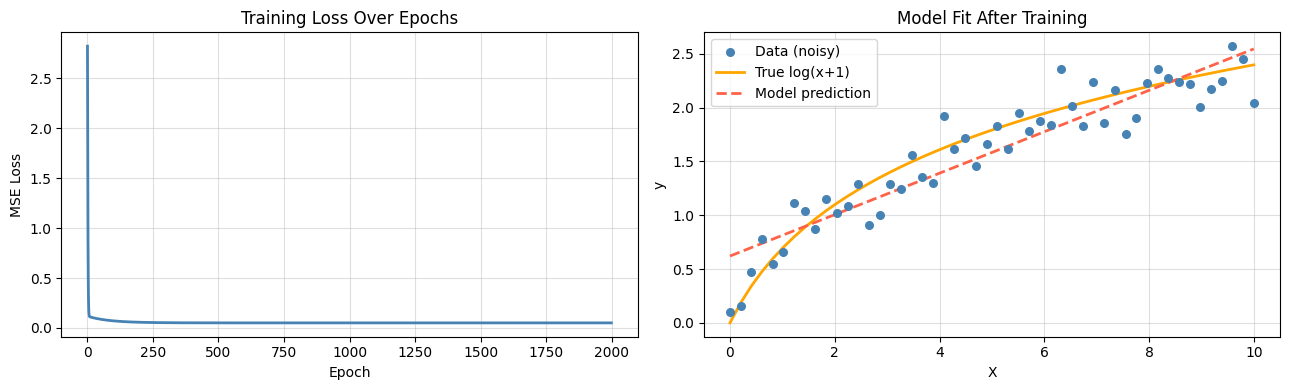

Initial loss : 2.82229
Final loss   : 0.05102
Improvement  : 98.2%


In [ ]:
# ── Plot 1: Training loss curve ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(loss_history, color='steelblue', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('Training Loss Over Epochs')
ax.grid(True, alpha=0.4)

# ── Plot 2: True vs Predicted ─────────────────────────────────────────────────
y_hat_final, _, _ = forward_pass(X, W1, b1, W2, b2)

ax = axes[1]
ax.scatter(X, y, color='steelblue', s=30, label='Data (noisy)', zorder=3)
ax.plot(X, np.log(X + 1), color='orange', linewidth=2, label='True log(x+1)')
ax.plot(X, y_hat_final,   color='tomato',  linewidth=2, linestyle='--', label='Model prediction')
ax.set_xlabel('X')
ax.set_ylabel('y')
ax.set_title('Model Fit After Training')
ax.legend()
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

print(f'Initial loss : {loss_history[0]:.5f}')
print(f'Final loss   : {loss_history[-1]:.5f}')
print(f'Improvement  : {((loss_history[0]-loss_history[-1])/loss_history[0]*100):.1f}%')